In [ ]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling
from sim_library.sequences import RR3_gate, RR3_adjMDFE_500kHz, exchange10_gate, PulseSequence, DownPulse, gen_MDFEup_seq, FreeEvolution
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
print((4*hbar*k_eff)**2/(kb*m))

2.3710021917250026e-05


In [ ]:
N = 50000
Temp = 5.93e-6

cycles = 16

rabi_freq = 2*pi*1e10
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
RR3.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[19] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
# beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list, _ = simulate_alg_cooling(basis=basis, sequence=RR3, n_atoms=N, temp=Temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                    #    alternating=True,
                                                        save_dir='data/algorithmic cooling',
                                                        )

In [2]:
path = Path("data/algorithmic cooling/2026-06-09_algcooling_f3_16cycles_6muK_50000atoms_1e+10Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [3]:
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

In [4]:
global_min = min([min(m) for m in moms_list])
global_max = max([max(m) for m in moms_list])
global_range = (global_min, global_max)

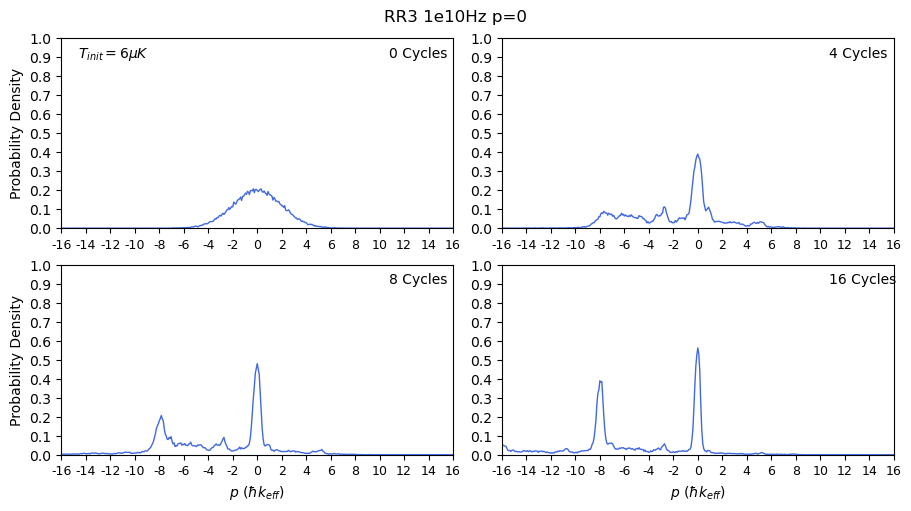

In [19]:


cycles_list = np.array([0,4,8,16])
index_list = np.array([0,8,16,32])
bin_width = 0.08

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bin_width=bin_width, title='RR3 1e10Hz p=0', temp=Temp, show=False, datarange=global_range,
                      ylim=1,
                     #   save_dir="plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png"
                       )

In [7]:
print(global_range)

(-57.36731160155801, 44.75585505887874)


Efficiency: 35.738 +/- 0.0046458 %
Temperature: 0.13158 +/- 0.0051337 muK
Center: -0.024125 +/- 0.0036089 hbark
Reduced chi-squared: 2.5458


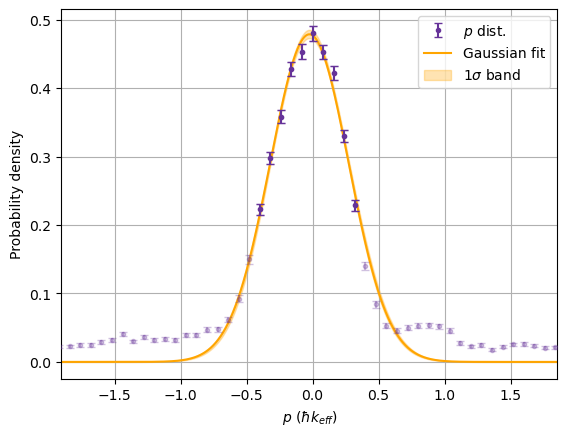

In [21]:
amp, T, shift, errs, chi2, _ = fit_gaussian(moms_list[-17], fracs=fracs_list[-17], range = global_range, bin_width=bin_width,         
                                            plot=True, 
                                            xscale=5,
                                            threshold=0.33,
                                            # plot_residuals=True,
                                            )


Efficiency: 32.384 +/- 0.00417 %
Temperature: 0.076605 +/- 0.0030971 muK
Center: -0.022203 +/- 0.0027752 hbark
Reduced chi-squared: 4.5373


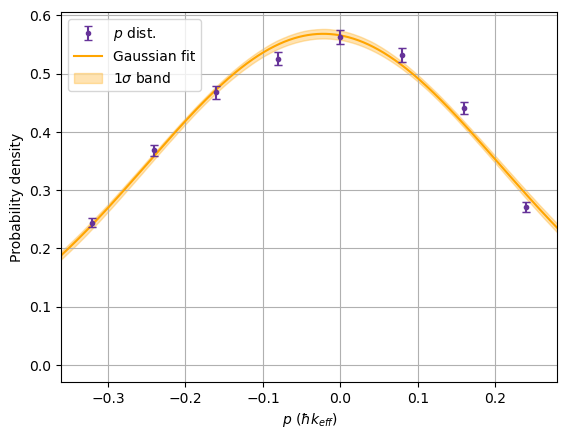

In [25]:
amp, T, shift, errs, chi2, _ = fit_gaussian(moms_list[-1], fracs=fracs_list[-1], range = global_range, bin_width=bin_width,         
                                            plot=True, 
                                            xscale=1,
                                            threshold=0.33,
                                            # plot_residuals=True,
                                            )


In [ ]:
### modified ex10 gate
rabi_freq = 2*pi*1e12
rabi_time = 2*pi/rabi_freq

detuning  = omega_eg/2
free_time = 2*pi/detuning

time_steps = 1

interf_cooler = PulseSequence()

pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/2

MDFE_1 = gen_MDFEup_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, +detuning)), duration=7*free_time/8) 

interf_cooler.add_pulses([pulse_1,
                freevolve_1,
                MDFE_1,
                pulse_1,
                ])
